In [35]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from dotenv import load_dotenv


In [36]:
## dedfinig then state 

class BastmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int
    strike_rate:float
    boundary_percentage:float
    bpb:float
    summary:str

In [ ]:
def calculate_strike_rate(State:BastmanState):
    sr=(State['runs']/State['balls'])*100
    State['strike_rate']=sr
    return {'strike_rate':sr}

def calculate_boundary_per_ball(state:BastmanState):
    bp=state['balls']/(state['fours']+state['sixes'])
    state['boundary_percentage']=bp
    return {'bpb':bp}

def calculate_boundary_percentage(state:BastmanState):
    bpb=((state['fours']*4+state['sixes']*6)/state['runs'])*100
    state['boudary_percentage']=bpb
    return {'boundary_percentage':bpb}

def get_summary(state:BastmanState):
    summary=f"""
          batsman strike rate is :{state['strike_rate']}\n
          batsman ball per boundary is :{state['bpb']}\n
          batsman boundary_percentage is : {state['boundary_percentage']}\n

"""
    state['summary']=summary

    return {'summary':summary} 


In [ ]:
## building graph 

graph=StateGraph(BastmanState)

## building node 

graph.add_node("strike_rate",calculate_strike_rate)
graph.add_node("boundary_percentage",calculate_boundary_percentage)
graph.add_node("boundary_per_ball",calculate_boundary_per_ball)
graph.add_node("summary",get_summary)

## adding edges :

graph.add_edge(START,"strike_rate")
graph.add_edge(START,"boundary_percentage")
graph.add_edge(START,"boundary_per_ball")
graph.add_edge("strike_rate","summary")
graph.add_edge("boundary_percentage","summary")
graph.add_edge("boundary_per_ball","summary")
graph.add_edge("summary",END)

workflow=graph.compile()  


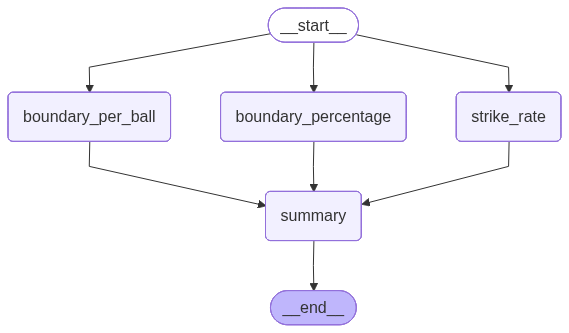

In [47]:
workflow

In [48]:
initial_state={
    'runs':100,
    'balls':50,
    'fours':6,
    'sixes':7
    
}

final_state=workflow.invoke(initial_state)

In [49]:
print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 7, 'strike_rate': 200.0, 'boundary_percentage': 66.0, 'bpb': 3.8461538461538463, 'summary': '\n          batsman strike rate is :200.0\n\n          batsman ball per boundary is :3.8461538461538463\n\n          batsman boundary_percentage is : 66.0\n\n\n'}
